<a href="https://colab.research.google.com/github/nnott3/KilterTransformer/blob/main/bert_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
# Enhanced Transformer for route difficulty prediction with spatial awareness.

# 1. ARCHITECTURE:
#     - Added 2D positional embeddings (pos_x, pos_y)
#     - Added other metadata features: route density, max reach distance
#     - Separate _train_epoch, _validate, _compute_grade_weights
#     - Added model_sumary

# 2. DATA PROCESSING:
#    - Sort holds by y
#   #  - Data augmentation: shuffle of non-start/finish holds during training
#   #  - Hold frequency by grade: Track how often each hold appears in different V-grades
#   #  - Hold co-occurrence patterns: Capture which holds commonly appear together

# 3. TRAINING:
#    - Early stopping
#    - Penalize errors more heavily on easier climbs (inverse grade weighting)


In [ ]:
!git clone https://github.com/nnott3/KilterTransformer.git

Cloning into 'KilterTransformer'...
remote: Enumerating objects: 141, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 141 (delta 20), reused 20 (delta 6), pack-reused 96 (from 1)
Receiving objects: 100% (141/141), 39.56 MiB | 8.53 MiB/s, done.
Resolving deltas: 100% (55/55), done.
Updating files: 100% (47/47), done.


In [ ]:
%cd KilterTransformer

/content/KilterTransformer


In [ ]:
!ls

bert_improved.ipynb  figs	 project_structure  saved_models
bert.ipynb	     gitignore	 pyproject.toml     src
data		     main.ipynb  readme.md	    utils_old
EDA.ipynb	     models	 req		    uv.lock


In [59]:
"""
Enhanced Transformer for route difficulty prediction with spatial awareness.
"""
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from transformers import BertConfig, BertModel, get_linear_schedule_with_warmup
from tqdm import tqdm
from collections import Counter
import datetime
import re

from src.data_processing import DataPreprocessing, HOLD_ID, HOLDCOORDINATES
from src.evaluation import Evaluation


class SpatialKilterBERT(nn.Module):
    """BERT with 2D positional embeddings and metadata integration."""

    def __init__(self, vocab_size, hidden_dim=128, num_layers=4, num_heads=8, dropout=0.1):
        super().__init__()

        config = BertConfig(
            vocab_size=vocab_size,
            hidden_size=hidden_dim,
            num_hidden_layers=num_layers,
            num_attention_heads=num_heads,
            intermediate_size=hidden_dim * 4,
            hidden_dropout_prob=dropout,
            attention_probs_dropout_prob=dropout,
            max_position_embeddings=100,
            pad_token_id=0
            )

        self.bert = BertModel(config)

        # 2D positional embeddings
        self.pos_x_embed = nn.Embedding(17, hidden_dim // 2)
        self.pos_y_embed = nn.Embedding(19, hidden_dim // 2)

        # Metadata projection
        self.angle_proj = nn.Linear(1, hidden_dim)
        self.metadata_proj = nn.Linear(2, hidden_dim)

        # Regression head
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, input_ids, pos_x, pos_y, angle, metadata, attention_mask=None):
        bert_out = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
            output_attentions=True
        )

        pos_embed = torch.cat([
            self.pos_x_embed(pos_x),
            self.pos_y_embed(pos_y)
        ], dim=-1)

        spatial_hidden = bert_out.last_hidden_state + pos_embed
        cls_token = spatial_hidden[:, 0]

        angle_emb = self.angle_proj(angle)
        meta_emb = self.metadata_proj(metadata)
        combined = torch.cat([cls_token + angle_emb, meta_emb], dim=-1)

        return self.regressor(combined).squeeze(-1), bert_out.attentions


In [60]:
class BoulderDataset(Dataset):
    """Dataset with spatial features. HuggingFace Datasets."""

    def __init__(self, routes_data, vocab, max_length=25, augment=False):
        self.routes = routes_data
        self.vocab = vocab
        self.max_length = max_length
        self.augment = augment

    def __len__(self):
        return len(self.routes)

    def __getitem__(self, idx):
        row = self.routes[idx]
        frames = row['frames']

        # # Augment: shuffle non-start/finish holds
        # if self.augment and len(holds_sorted) > 2:
        #     start_finish = [h for h in holds_sorted if list(h.values())[0] in [14, 15]]
        #     middle = [h for h in holds_sorted if list(h.values())[0] not in [14, 15]]
        #     np.random.shuffle(middle)
        #     holds_sorted = start_finish + middle

        # sort by position
        tokens, pos_x, pos_y = self._tokenize_with_positions(frames)

        # Metadata features
        coords = np.array(list(zip(pos_x[1:-1], pos_y[1:-1])))  # exclude CLS/SEP
        reaches = np.linalg.norm(np.diff(coords, axis=0), axis=1)
        x_min, y_min = coords.min(axis=0)
        x_max, y_max = coords.max(axis=0)
        width = x_max - x_min
        height = y_max - y_min
        density = len(coords)/(width*height) if (width and height) else 0
        max_reach = max(reaches)


        angle = row['angle_y'] if row['angle_y'] is not None and str(row['angle_y']) != 'nan' else 0.0
        difficulty = row['display_difficulty']

        # Pad sequences
        attention_mask = [1] * len(tokens)
        pad_len = self.max_length - len(tokens)
        tokens.extend([0] * pad_len)
        pos_x.extend([0] * pad_len)
        pos_y.extend([0] * pad_len)
        attention_mask.extend([0] * pad_len)

        return {
            'input_ids': torch.LongTensor(tokens[:self.max_length]),
            'pos_x': torch.LongTensor(pos_x[:self.max_length]),
            'pos_y': torch.LongTensor(pos_y[:self.max_length]),
            'angle': torch.FloatTensor([angle]),
            'metadata': torch.FloatTensor([density, max_reach]),
            'attention_mask': torch.FloatTensor(attention_mask[:self.max_length]),
            'difficulty': torch.FloatTensor([difficulty]),
            'v_grade': row['v_grade']
        }

    def _tokenize_with_positions(self, frames):
        """Convert frames to tokens with 2D positions."""
        tokens = [1]  # [CLS]
        pos_x = [0]
        pos_y = [0]

        frame_split = [f for f in frames.split('_')
                        if ('angle' not in f) and ('grade' not in f)]

        hold_info = []
        for f in frame_split[: (self.max_length - 2)]:
            token = self.vocab.get(f, 0)
            x, y = HOLDCOORDINATES[HOLD_ID.index(int(f[-4:]))]
            hold_info.append((f, token, x, y))

        def sort_logic(item):
            f, token, x, y = item
            if "start" in f:
                order = 0
            elif "finish" in f:
                order = 2
            else:
                order = 1
            return (order, -y)  # sort by order first, then pos_y desc

        hold_info = sorted(hold_info, key=sort_logic)
        for f, token, x, y in hold_info:
            tokens.append(token)
            pos_x.append(int(x * 16 / 1800))  # Scale x to 0-16
            pos_y.append(int(y * 18 / 1200))  # Scale y to 0-18


        tokens.append(2)  # [SEP]
        pos_x.append(0)
        pos_y.append(0)

        return tokens, pos_x, pos_y




In [61]:
class KilterEncoder:

    def __init__(self, model_name='enhanced_transformer', hidden_dim=128, num_layers=4):
        self.model_name = model_name
        self.max_length = 25
        self.vocab = self._build_vocab()
        self.vocab_size = len(self.vocab)
        self.model = SpatialKilterBERT(len(self.vocab), hidden_dim, num_layers)
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        self.scaler = GradScaler()

    def _build_vocab(self):
        """Build vocabulary with hand_or_foot encoding."""
        vocab = {'[PAD]': 0, '[CLS]': 1, '[SEP]': 2}
        token_id = 3
        for angle in range(20, 60, 5):
            vocab[f"angle{angle}"] = token_id
            token_id += 1

        for hold_id in HOLD_ID:
            for func in ['start', 'hand', 'finish', 'feet']:
                vocab[f"{func}{hold_id}"] = token_id
                token_id += 1
        return vocab


    def train_model(self, train_data, val_data, epochs=30, batch_size=64, lr=2e-4, early_stop=3):
        """Train with mixed precision and early stopping."""

        train_dataset = BoulderDataset(train_data, self.vocab,  augment=True)
        val_dataset = BoulderDataset(val_data, self.vocab, augment=False)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=0.01)
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=len(train_loader) * epochs // 10,
            num_training_steps=len(train_loader) * epochs
            )

        grade_weights = self._compute_grade_weights(train_data)

        best_val_loss = float('inf')
        patience_counter = 0

        print(f"Training {self.model_name} ...")

        for epoch in range(epochs):
            train_loss = self._train_epoch(train_loader, optimizer, scheduler, grade_weights, epoch, epochs)
            val_loss = self._validate(val_loader, grade_weights)

            print(f"Epoch {epoch+1}/{epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
                  f"LR: {scheduler.get_last_lr()[0]:.2e}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                self.save_model()
            else:
                patience_counter += 1
                if patience_counter >= early_stop:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

            if epoch % 10 == 0 and epoch != 0:
                timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
                self.save_model(f"{self.model_name}_{epoch}_{timestamp}.pt")

    def _train_epoch(self, loader, optimizer, scheduler, grade_weights, epoch, total_epochs):
        """Single training epoch with mixed precision."""
        self.model.train()
        total_loss = 0

        for batch in tqdm(loader, desc=f"Epoch {epoch+1}/{total_epochs}", leave=False):
            v_grades = batch.pop('v_grade')
            batch = {k: v.to(self.device) for k, v in batch.items()}

            optimizer.zero_grad()

            with autocast():
                pred, _ = self.model(
                    batch['input_ids'], batch['pos_x'], batch['pos_y'],
                    batch['angle'], batch['metadata'], batch['attention_mask']
                )

                weights = torch.tensor([grade_weights.get(g, 1.0) for g in v_grades],
                                      device=self.device)
                loss = (nn.SmoothL1Loss(reduction='none')(pred, batch['difficulty'].squeeze()) * weights).mean()

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.scaler.step(optimizer)
            self.scaler.update()
            scheduler.step()

            total_loss += loss.item()

        return total_loss / len(loader)

    def _validate(self, loader, grade_weights):
        """Validation with weighted loss."""
        self.model.eval()
        total_loss = 0

        with torch.no_grad():
            for batch in loader:
                v_grades = batch.pop('v_grade')
                batch = {k: v.to(self.device) for k, v in batch.items()}

                pred, _ = self.model(
                    batch['input_ids'], batch['pos_x'], batch['pos_y'],
                    batch['angle'], batch['metadata'], batch['attention_mask']
                )

                weights = torch.tensor([grade_weights.get(g, 1.0) for g in v_grades],
                                      device=self.device)
                loss = (nn.SmoothL1Loss(reduction='none')(pred, batch['difficulty'].squeeze()) * weights).mean()
                total_loss += loss.item()

        return total_loss / len(loader)

    def _compute_grade_weights(self, data):
        """Compute weights to penalize errors on easier grades more."""
        # Convert to list for counting
        grades_list = [row['v_grade'] for row in data]
        grade_counts = Counter(grades_list)

        def grade_to_num(grade_str):
            match = re.search(r'\d+', str(grade_str))
            return int(match.group()) if match else 0

        max_grade_num = max(grade_to_num(g) for g in grade_counts.keys())

        weights = {grade: (max_grade_num - grade_to_num(grade) + 1) / max_grade_num
                  for grade in grade_counts.keys()}
        return weights

    def predict(self, routes_data, batch_size=64):
        """Predict with attention extraction."""
        dataset = BoulderDataset(routes_data, self.vocab, augment=False)
        loader = DataLoader(dataset, batch_size=batch_size)

        self.model.eval()
        predictions = []
        attentions = []

        with torch.no_grad():
            for batch in loader:
                batch.pop('v_grade')
                batch = {k: v.to(self.device) for k, v in batch.items()}

                pred, attn = self.model(
                    batch['input_ids'], batch['pos_x'], batch['pos_y'],
                    batch['angle'], batch['metadata'], batch['attention_mask']
                )

                predictions.extend(pred.cpu().numpy())
                if attn:
                    attentions.append(attn[-1].cpu().numpy())

        return np.array(predictions), attentions

    def save_model(self, name=None):
        if name is None:
            name = f'{self.model_name}.pt'
        torch.save({
            'model_state': self.model.state_dict(),
            'vocab': self.vocab,
        }, f'saved_models/{name}')

    def load_model(self, path=None):
        if path is None:
            path = f'{self.model_name}.pt'
        checkpoint = torch.load(f'saved_models/{path}', map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state'])
        self.vocab = checkpoint['vocab']
        self.model.eval()

    def model_summary(self):
        """Print model architecture and parameters."""
        print(f"\n{'='*60}")
        print(f"Model: {self.model_name}")
        print(f"{'='*60}")
        print(f"Vocabulary size: {len(self.vocab)}")
        print(f"Max sequence length: {self.max_length}")

        total_params = sum(p.numel() for p in self.model.parameters())
        trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)

        print(f"\nTotal parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,}")
        print(f"Model size: {total_params * 4 / 1024**2:.2f} MB")

        print(f"\nArchitecture:")
        for name, module in self.model.named_children():
            params = sum(p.numel() for p in module.parameters())
            print(f"  {name}: {params:,} parameters")
        print(f"{'='*60}\n")

In [64]:
from datasets import ClassLabel, disable_progress_bars

disable_progress_bars()

dp = DataPreprocessing()
climbs = dp.load_climbs()
print(f"Dataset: {len(climbs)} climbs")

num_classes = len(set(climbs["v_grade"]))
climbs = climbs.cast_column("v_grade", ClassLabel(num_classes=num_classes))

# Split train/test
climbs = climbs.train_test_split(test_size=0.1, seed=42, stratify_by_column="v_grade")
test_df = climbs['test']

# Split train/val
train_val = climbs['train'].train_test_split(test_size=0.15, seed=42, stratify_by_column="v_grade")
train_df = train_val['train']
val_df = train_val['test']

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

model_name = 'improved_bert_v0'
encoder = KilterEncoder(model_name=model_name, hidden_dim=256, num_layers=4)
print(f"Vocabulary size: {encoder.vocab_size}")
print(f"Model parameters: {sum(p.numel() for p in encoder.model.parameters()):,}")
print(f"{encoder.model_summary()}")
print(f"Device: {encoder.device}")

encoder.train_model(train_df, val_df, epochs=40, batch_size=64, lr=2e-4)



Loaded 76992 routes from cache data/climbs_cleaned.csv
Dataset: 76992 climbs
Train: 58898, Val: 10394, Test: 7700
Vocabulary size: 1915
Model parameters: 3,879,681

Model: improved_bert_v0
Vocabulary size: 1915
Max sequence length: 25

Total parameters: 3,879,681
Trainable parameters: 3,879,681
Model size: 14.80 MB

Architecture:
  bert: 3,741,696 parameters
  pos_x_embed: 2,176 parameters
  pos_y_embed: 2,432 parameters
  angle_proj: 512 parameters
  metadata_proj: 768 parameters
  regressor: 132,097 parameters

None
Device: cuda


/tmp/ipython-input-4091572046.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler()


Training improved_bert_v0 ...


Epoch 1/40:   0%|          | 0/921 [00:00<?, ?it/s]/tmp/ipython-input-4091572046.py:121: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/40 | Train: 15.4266 | Val: 12.4093 | LR: 5.00e-05


...

Epoch 16/40 | Train: 0.7768 | Val: 0.8329 | LR: 1.33e-04


Epoch 17/40 | Train: 0.7494 | Val: 0.8325 | LR: 1.28e-04


Epoch 18/40 | Train: 0.7309 | Val: 0.8370 | LR: 1.22e-04


Epoch 19/40 | Train: 0.7136 | Val: 0.8630 | LR: 1.17e-04


Epoch 20/40 | Train: 0.7023 | Val: 0.8623 | LR: 1.11e-04
Early stopping at epoch 20



Evaluating on test set...

improved_bert_v0 Performance:
  R²:   0.8059
  MAE:  1.2384
  RMSE: 1.6329
  Within ±1 V-grade: 83.84%


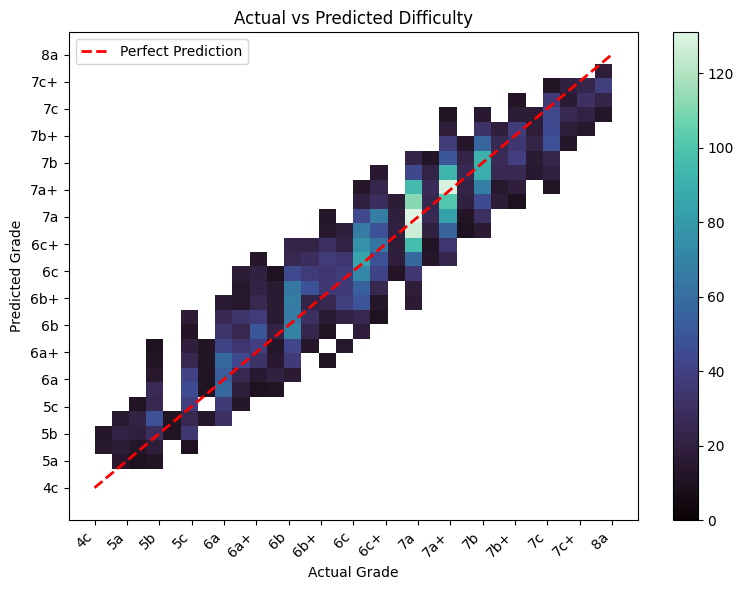

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
from src.data_processing import DataPreprocessing
from src.evaluation import Evaluation


# Load best model
encoder.load_model('improved_bert_v0.pt')

# Evaluate
print("\nEvaluating on test set...")
y_test = np.array(test_df['display_difficulty'])
y_pred, attention = encoder.predict(test_df)

evaluator = Evaluation()
scores = evaluator.get_scores(y_test, y_pred, "improved_bert_v0")

evaluator.plot_predictions(y_test, y_pred)

In [ ]:
from getpass import getpass
token = getpass("Enter your GitHub token: ")

!git config --global user.email "treepatchantaurai@gmail.com"
!git config --global user.name "nnott3"
!git remote set-url origin https://{token}@github.com/nnott3/KilterTransformer.git



In [66]:
!git add saved_models/improved_bert_v1.pt
!git add saved_models/improved_bert_v1_10_20251030-124806.pt
!git add saved_models/improved_bert_v1_10_20251030-131117.pt

In [67]:
!git commit -m "improved_bert_v1 (256 dim) (83.8%)"

[main 1c0779b] improved_bert_v1 (256 dim) (83.8%)
 3 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 saved_models/improved_bert_v1.pt
 create mode 100644 saved_models/improved_bert_v1_10_20251030-124806.pt
 create mode 100644 saved_models/improved_bert_v1_10_20251030-131117.pt


# Accuracy Record
- Basic BERT (83%)
- 1st Add-on (79.8%)
  - 2D positional embeddings
  - Features (Density + Max_reach)
  - Early stopping = 5
  - weights to penalize errors on easier grades more
- 2nd (78.5%)
  - hold freq, co-occurence

In [58]:
train_df['frames'][0]

'angle40_grade23_start1109_start1125_hand1163_hand1184_hand1235_hand1254_hand1283_hand1304_hand1354_finish1391_feet1459_feet1464_feet1476_feet1507_feet1534'